## Executive Summary

**Purpose:** Provide nonlinear reluctance models for MEC solver

**What it does:** Implement permeability models for magnetic materials.

### Why It Matters
MEC solver needs reluctance(flux) relationships; these models provide that.

### Quick Start
**Inputs:** Material properties, flux density

**Outputs:** Reluctance values for magnetic circuit analysis

## How It Fits Into the Motor Design Workflow

**Upstream (depends on):** Used by 04_mec_solver.ipynb to compute magnetic circuit

**Downstream (used by):** See notebook connections

In [8]:
#| hide
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from abc import ABC, abstractmethod
import math

## Theory: Magnetic Permeability

Magnetic permeability μ relates flux density **B** to field strength **H**:

$$B = \mu \cdot H = \mu_0 \cdot \mu_r \cdot H$$

where:
- $\mu_0 = 4\pi \times 10^{-7}$ H/m is permeability of free space
- $\mu_r$ is relative permeability (material property)

For nonlinear materials, permeability changes with B. The MEC solver requires both:
1. $\mu(B)$ — permeability at flux density B
2. $\frac{d\mu}{dB}$ — derivative for Newton-Raphson linearization

In [9]:
#| export
MU0 = 4e-7 * np.pi  # H/m

class PermeabilityModel(ABC):
    """Abstract interface for permeability models used by the MEC solver."""

    @abstractmethod
    def mu(self, B: float) -> float:
        r"""Return permeability μ [H/m] at flux density *B* [T]."""

    @abstractmethod
    def dmu_dB(self, B: float) -> float:
        r"""Return dμ/dB [H/m·T⁻¹] at flux density *B* [T]."""
        pass

## Linear Permeability Model

For linear materials (no saturation), permeability is constant:

$$\mu(B) = \mu_0 \cdot \mu_r$$
$$\frac{d\mu}{dB} = 0$$

This applies to air gaps and weakly magnetic materials.

In [10]:
#| export
class LinearPermeabilityModel(PermeabilityModel):
    """
    Constant permeability μ = μ₀ · μᵣ.

    Parameters
    ----------
    mu_r:
        Relative permeability (dimensionless). Default is 1 (free space).
    """

    def __init__(self, mu_r: float = 1.0) -> None:
        if mu_r <= 0:
            raise ValueError(f"mu_r must be positive, got {mu_r}")
        self._mu = MU0 * mu_r

    def mu(self, B: float) -> float:
        """Return constant permeability."""
        return self._mu

    def dmu_dB(self, B: float) -> float:
        """Derivative is zero for linear model."""
        return 0.0

## Spline Permeability Model

For nonlinear materials with measured B-H curves, fit a cubic spline:

$$\mu(B) = \mu_0 \cdot \frac{H(B)}{B}$$

The spline provides both μ(B) and its derivative dμ/dB for Newton-Raphson.

**Assumption:** Data starts at origin (H=0, B=0)  
**Symmetry:** Negative B uses odd symmetry: μ(-B) = μ(B)

In [11]:
#| export
class SplinePermeabilityModel(PermeabilityModel):
    """
    Permeability model built from tabulated B-H data via a cubic spline.

    The data are assumed to start at (H=0, B=0). Negative-B evaluation
    uses odd symmetry: μ(−|B|) = μ(|B|), dμ/dB(−|B|) = −dμ/dB(|B|).

    Parameters
    ----------
    H_data:
        Array of field strengths [A/m], monotonically increasing from 0.
    B_data:
        Corresponding flux densities [T].

    Class methods
    -------------
    from_steel_grade(grade)
        Convenience constructor that reads the ``bh_data`` DataFrame of an
        :class:`emachines.magnetics.SteelGrade` instance.
    """

    def __init__(
        self,
        H_data,  # Sequence[float]
        B_data,  # Sequence[float]
    ) -> None:
        H = np.asarray(H_data, dtype=float)
        B = np.asarray(B_data, dtype=float)

        if H.shape != B.shape:
            raise ValueError("H_data and B_data must have the same length.")
        if H[0] != 0.0 or B[0] != 0.0:
            raise ValueError("B-H data must start at (H=0, B=0).")
        if not np.all(np.diff(H) > 0):
            raise ValueError("H_data must be strictly increasing.")

        # μ(B) = μ₀ * H/B — defined for B > 0 only
        B_pos = B[1:]
        H_pos = H[1:]
        mu_pos = MU0 * H_pos / B_pos

        # Prepend B=0 using initial linear slope
        mu_at_0 = MU0 * H_pos[0] / B_pos[0]
        B_knots = np.concatenate([[0.0], B_pos])
        mu_knots = np.concatenate([[mu_at_0], mu_pos])

        self._B_max = B_knots[-1]
        self._mu_min = mu_knots[-1]
        self._cs = CubicSpline(B_knots, mu_knots)
        self._cs_deriv = self._cs.derivative()

    @classmethod
    def from_steel_grade(cls, grade) -> "SplinePermeabilityModel":
        """
        Create a SplinePermeabilityModel from a
        :class:`emachines.magnetics.SteelGrade`.
        """
        df = grade.bh_data
        # Find H and B columns by substring match
        h_col = next(c for c in df.columns if "H" in c.upper() and "B" not in c.upper())
        b_col = next(c for c in df.columns if c.upper().startswith("B"))
        H = df[h_col].to_numpy(dtype=float)
        B = df[b_col].to_numpy(dtype=float)
        # Sort and ensure starts at origin
        order = np.argsort(H)
        H, B = H[order], B[order]
        if H[0] != 0:
            H = np.concatenate([[0.0], H])
            B = np.concatenate([[0.0], B])
        return cls(H, B)

    def mu(self, B: float) -> float:
        """Return permeability at flux density B."""
        absB = abs(B)
        if absB >= self._B_max:
            return self._mu_min
        return float(self._cs(absB))

    def dmu_dB(self, B: float) -> float:
        """Return derivative dμ/dB at flux density B."""
        absB = abs(B)
        if absB >= self._B_max:
            return 0.0
        sign = 1.0 if B >= 0 else -1.0
        return sign * float(self._cs_deriv(absB))

## Shane-Sudhoff Analytical Model

Analytical model published in:
> Shane, S.D. & Sudhoff, S.D. (2010). "Refinements in Anhysteretic Characterization and Permeability Modeling." IEEE Trans. Magn., 46(11).

The model uses an auxiliary function f(B) with piecewise exponential terms:

$$f(B) = \frac{\mu_r}{\mu_r - 1} + \sum_n \left[ a_n |B| + d_n \log(e_n + z_n e^{-b_n |B|}) \right]$$

where derived constants are:
- $d_n = a_n / b_n$
- $z_n = (\gamma_n - 1) / \gamma_n$
- $e_n = 1 - z_n$

Then:
$$\mu(B) = \mu_0 \cdot \frac{f}{f - 1}$$

In [ ]:
#| export
class ShanesudhoffModel(PermeabilityModel):
    """
    Shane-Sudhoff (2010) analytical permeability model.

    Parameters
    ----------
    mu_r:
        Initial relative permeability.
    a, b, gamma:
        Sequences of equal length, one entry per term.
    mu0:
        Permeability of free space [H/m]. Default: 4π×10⁻⁷.

    Class methods
    -------------
    ferrite_3C90()
        Returns a ShanesudhoffModel with the 3C90 ferrite parameters from
        the MEC 3.2 toolbox example (Sudhoff, 2014).
    """

    def __init__(
        self,
        mu_r: float,
        a,  # Sequence[float]
        b,  # Sequence[float]
        gamma,  # Sequence[float]
        mu0: float = None,
    ) -> None:
        if mu0 is None:
            mu0 = MU0
        a = np.asarray(a, dtype=float)
        b = np.asarray(b, dtype=float)
        gamma = np.asarray(gamma, dtype=float)
        if not (len(a) == len(b) == len(gamma)):
            raise ValueError("a, b, gamma must all have the same length.")

        self._mu_r = float(mu_r)
        self._a = a
        self._b = b
        self._mu0 = float(mu0)

        # Pre-compute derived constants
        self._d = a / b
        self._z = (gamma - 1.0) / gamma
        self._e = 1.0 - self._z
        self._h = self._mu0 * a * self._z * b

    def _f_and_df(self, absB: float):
        """Return (f, df/d|B|) at |B|."""
        eb = np.exp(-self._b * absB)
        arg = self._e + self._z * eb

        sum_terms = np.sum(self._a * absB + self._d * np.log(arg))
        f = self._mu_r / (self._mu_r - 1.0) + sum_terms

        dlog_dabs = -self._d * self._z * self._b * eb / arg
        df = np.sum(self._a + dlog_dabs)

        return f, df

    def mu(self, B: float) -> float:
        """Return permeability at flux density B."""
        absB = abs(float(B))
        f, _ = self._f_and_df(absB)
        return self._mu0 * f / (f - 1.0)

    def dmu_dB(self, B: float) -> float:
        """Return derivative dμ/dB at flux density B."""
        absB = abs(float(B))
        f, df = self._f_and_df(absB)
        fm1 = f - 1.0
        sign = 1.0 if B >= 0 else -1.0
        return -self._mu0 * df / (fm1 * fm1) * sign

    @classmethod
    def ferrite_3C90(cls) -> "ShanesudhoffModel":
        """
        3C90 ferrite parameters from MEC 3.2 toolbox (Sudhoff, 2014).

        μᵣ = 22 340.9259
        """
        return cls(
            mu_r=22340.9259,
            a=[1.1542, 0.049742, 0.049644, 0.041155],
            b=[431.1763, 2.29503, 15.04824, 74.28908],
            gamma=[0.4742, 2.7955, 0.59862, 0.43996],
        )

## Example: Compare Permeability Models

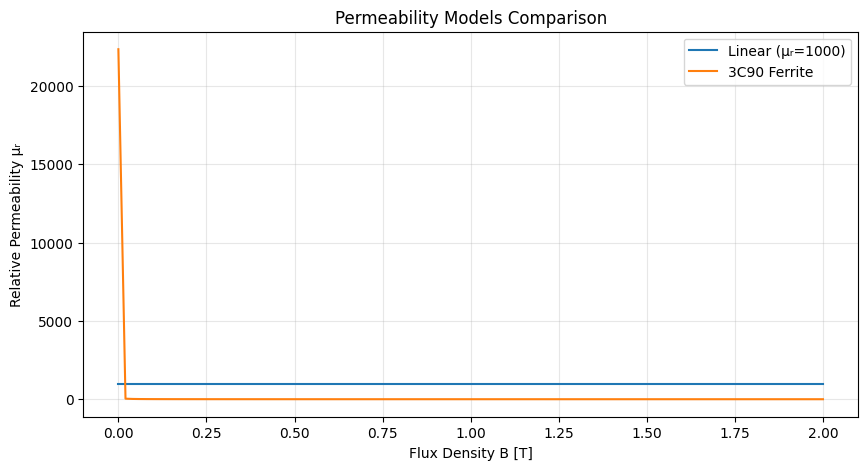

In [13]:
# Create models
linear = LinearPermeabilityModel(mu_r=1000)
ferrite = ShanesudhoffModel.ferrite_3C90()

# Sample B values
B_range = np.linspace(0, 2.0, 100)

# Evaluate models
mu_linear = np.array([linear.mu(B) for B in B_range])
mu_ferrite = np.array([ferrite.mu(B) for B in B_range])

# Plot
plt.figure(figsize=(10, 5))
plt.plot(B_range, mu_linear / 4e-7 / np.pi, label='Linear (μᵣ=1000)')
plt.plot(B_range, mu_ferrite / 4e-7 / np.pi, label='3C90 Ferrite')
plt.xlabel('Flux Density B [T]')
plt.ylabel('Relative Permeability μᵣ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Permeability Models Comparison')
plt.show()

## Tests

In [14]:
# Test LinearPermeabilityModel
mu0 = 4e-7 * np.pi
mu_r = 1000
linear = LinearPermeabilityModel(mu_r=mu_r)

assert linear.mu(0.5) == mu0 * mu_r, "Linear model should be constant"
assert linear.dmu_dB(0.5) == 0.0, "Linear model derivative should be zero"

# Test with mu_r=1 (free space)
air = LinearPermeabilityModel(mu_r=1.0)
assert air.mu(1.0) == mu0, "Free space permeability incorrect"

print("✓ LinearPermeabilityModel tests passed")

# Test ShanesudhoffModel
ferrite = ShanesudhoffModel.ferrite_3C90()

# At B=0, should return μ₀·μᵣ
mu_at_0 = ferrite.mu(0.0)
mu_r_initial = mu_at_0 / mu0
assert mu_r_initial > 1000, "Initial permeability should be high"

# Check that permeability decreases with increasing B (saturation)
mu_0_1 = ferrite.mu(0.1)
mu_1_0 = ferrite.mu(1.0)
assert mu_1_0 < mu_0_1, "Ferrite should saturate"

# Verify odd symmetry of derivative
df_pos = ferrite.dmu_dB(0.5)
df_neg = ferrite.dmu_dB(-0.5)
assert np.isclose(df_pos, -df_neg), "Derivative should have odd symmetry"

print("✓ ShanesudhoffModel tests passed")

# Test error handling
try:
    bad_linear = LinearPermeabilityModel(mu_r=0)
    assert False, "Should reject non-positive mu_r"
except ValueError:
    print("✓ Error handling tests passed")

✓ LinearPermeabilityModel tests passed
✓ ShanesudhoffModel tests passed
✓ Error handling tests passed
